# Food to Recipe Generation using CLIP + Transformer

## Project Overview

This notebook implements a deep learning system that generates cooking recipes from images of food using CLIP and Transformer architectures.

### Goal
Develop a cross-modal translation model that:
- Takes images of food as input
- Generates complete recipes with ingredients and cooking steps
- Uses visual information (ingredients, cooking method, presentation) to create structured recipe text

### Approach
1. **CLIP Image Encoder**: Use frozen ViT-B/32 to extract visual features
2. **Transformer Decoder**: GPT-like model to generate recipe text
3. **Training**: Focus on decoder training with CLIP features as context
4. **Evaluation**: Monitor loss, check overfitting, experiment with hyperparameters


### Installation Requirements

Run this cell first to install required packages:
```
pip install torch torchvision
pip install transformers
pip install pillow pandas matplotlib seaborn
pip install accelerate
```


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import zipfile
import os
import re
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Hugging Face Libraries
from transformers import (
    CLIPProcessor, CLIPModel,
    GPT2LMHeadModel, GPT2Tokenizer,
    GPT2Config,
    get_linear_schedule_with_warmup
)
from transformers import Trainer, TrainingArguments

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Set device - MULTI-GPU SUPPORT
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Found {num_gpus} GPU(s)")
    
    # Use multiple GPUs if available
    if num_gpus > 1:
        device = torch.device("cuda")
        use_multi_gpu = True
        print(f"Using MULTI-GPU training with {num_gpus} GPUs")
        for i in range(num_gpus):
            gpu_name = torch.cuda.get_device_name(i)
            print(f"  GPU {i}: {gpu_name}")
    else:
        device = torch.device("cuda")
        use_multi_gpu = False
        print(f"Using single GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    use_multi_gpu = False
    print("Using CPU (No GPU available)")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")

print("\n✓ Libraries imported successfully!")


Found 2 GPU(s)
Using MULTI-GPU training with 2 GPUs
  GPU 0: NVIDIA GeForce RTX 3090
  GPU 1: NVIDIA GeForce RTX 3090
PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA version: 12.8

✓ Libraries imported successfully!


## 1. Dataset Loading and Exploration


In [2]:
# Extract ONLY the Food Ingredients dataset (NOT RecipeNLG)
zip_files = [
    "Food Ingredients and Recipe Dataset with Image Name Mapping.csv.zip"
]

# Extract dataset
for zip_file in zip_files:
    if os.path.exists(zip_file):
        print(f"Extracting {zip_file}...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(".")
        print(f"✓ Extracted successfully!")

# Get the Food Ingredients CSV file
target_csv = "Food Ingredients and Recipe Dataset with Image Name Mapping.csv"
if os.path.exists(target_csv):
    print(f"\n✓ Found dataset: {target_csv}")
    extracted_files = [target_csv]  # Only use this CSV
    print(f"✓ Using ONLY '{target_csv}' - RecipeNLG_dataset will be IGNORED")
else:
    print(f"\n✗ Dataset '{target_csv}' not found!")
    extracted_files = []



✓ Found dataset: Food Ingredients and Recipe Dataset with Image Name Mapping.csv
✓ Using ONLY 'Food Ingredients and Recipe Dataset with Image Name Mapping.csv' - RecipeNLG_dataset will be IGNORED


### 1.1 Data Exploration


In [3]:
# Load and explore the dataset
main_dataset = None
for csv_file in extracted_files:
    print(f"\n{'='*60}")
    print(f"Dataset: {csv_file}")
    print('='*60)
    df = pd.read_csv(csv_file)
    print(f"\nShape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nFirst few rows:")
    print(df.head())
    print(f"\nData types:")
    print(df.dtypes)
    
    # Store the main dataset
    if main_dataset is None:
        main_dataset = df
        
print("\n" + "="*60)
print(f"\nUsing main dataset with {main_dataset.shape[0]} samples")
print(f"Columns: {list(main_dataset.columns)}")



Dataset: Food Ingredients and Recipe Dataset with Image Name Mapping.csv

Shape: (13501, 6)

Columns: ['Unnamed: 0', 'Title', 'Ingredients', 'Instructions', 'Image_Name', 'Cleaned_Ingredients']

First few rows:
   Unnamed: 0                                              Title  \
0           0  Miso-Butter Roast Chicken With Acorn Squash Pa...   
1           1                    Crispy Salt and Pepper Potatoes   
2           2                        Thanksgiving Mac and Cheese   
3           3                 Italian Sausage and Bread Stuffing   
4           4                                       Newton's Law   

                                         Ingredients  \
0  ['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...   
1  ['2 large egg whites', '1 pound new potatoes (...   
2  ['1 cup evaporated milk', '1 cup whole milk', ...   
3  ['1 (¾- to 1-pound) round Italian loaf, cut in...   
4  ['1 teaspoon dark brown sugar', '1 teaspoon ho...   

                                        In

In [4]:
# Fix: Select the dataset with Image_Name column  
print("\n" + "="*60)
print("SELECTING CORRECT DATASET WITH Image_Name COLUMN")
print("="*60)

# Re-load and select the correct dataset
all_datasets = {}
for csv_file in extracted_files:
    df = pd.read_csv(csv_file)
    all_datasets[csv_file] = df
    has_image_name = 'Image_Name' in df.columns
    print(f"\n{'-'*60}")
    print(f"File: {csv_file}")
    print(f"  Has Image_Name column: {'✓ YES' if has_image_name else '✗ NO'}")
    print(f"  Rows: {df.shape[0]}")

# Select the dataset with Image_Name
for csv_file, df in all_datasets.items():
    if 'Image_Name' in df.columns:
        main_dataset = df
        print(f"\n{'='*60}")
        print(f"✓ SELECTED: {csv_file}")
        print(f"  Rows: {main_dataset.shape[0]}")
        print(f"  Columns: {list(main_dataset.columns)}")
        print(f"\nSample Image_Name values:")
        print(main_dataset['Image_Name'].head(3).tolist())
        break
else:
    if extracted_files:
        print(f"\n⚠️  No Image_Name found, using first dataset")
        main_dataset = all_datasets[extracted_files[0]]

print("\n" + "="*60)



SELECTING CORRECT DATASET WITH Image_Name COLUMN

------------------------------------------------------------
File: Food Ingredients and Recipe Dataset with Image Name Mapping.csv
  Has Image_Name column: ✓ YES
  Rows: 13501

✓ SELECTED: Food Ingredients and Recipe Dataset with Image Name Mapping.csv
  Rows: 13501
  Columns: ['Unnamed: 0', 'Title', 'Ingredients', 'Instructions', 'Image_Name', 'Cleaned_Ingredients']

Sample Image_Name values:
['miso-butter-roast-chicken-acorn-squash-panzanella', 'crispy-salt-and-pepper-potatoes-dan-kluger', 'thanksgiving-mac-and-cheese-erick-williams']



## 2. Data Preprocessing


### 1.1.6 Image Finding Function

Setup function to locate image files. Searches **'food_images/Food Images/'** directory first for actual food images.


In [5]:
# Function to find actual images based on Image_Name
def find_image_file(image_name, search_dirs=['food_images/Food Images', 'food_images', '.', 'images', 'dataset']):
    """
    Find the actual image file based on the Image_Name from the CSV.
    Searches in 'food_images/Food Images/' directory first!
    """
    # Common image extensions
    extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
    
    # Try different directory locations
    for directory in search_dirs:
        if not os.path.exists(directory):
            continue
            
        # Try with different extensions
        for ext in extensions:
            path = os.path.join(directory, image_name + ext)
            if os.path.exists(path) and os.path.isfile(path):
                return path
                
        # Try with image_name as-is (in case it already has extension or path)
        path = os.path.join(directory, image_name)
        if os.path.exists(path) and os.path.isfile(path):
            return path
    
    return None

# Check if food_images directory exists
print("Checking for 'food_images/Food Images' directory...")
food_images_path = 'food_images/Food Images'
if os.path.exists(food_images_path):
    image_files = [f for f in os.listdir(food_images_path) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"✓ Found '{food_images_path}' directory with {len(image_files)} image files!")
    print(f"Sample images: {image_files[:3]}")
elif os.path.exists('food_images'):
    print(f"✓ Found 'food_images' directory (checking subdirectories...)")
    subdirs = [d for d in os.listdir('food_images') if os.path.isdir(f"food_images/{d}")]
    print(f"Subdirectories: {subdirs}")
else:
    print("⚠️  'food_images' directory not found. Will search in other locations.")

print("\n✓ Image finding function ready!")


Checking for 'food_images/Food Images' directory...
✓ Found 'food_images/Food Images' directory with 13582 image files!
Sample images: ['pate-brisee-tart-crust-354316.jpg', 'harissa-and-maple-roasted-carrots-51255090.jpg', 'rustic-nut-bars-233301.jpg']

✓ Image finding function ready!


## 3. Load Models: CLIP + GPT-2

### 3.1 Initialize CLIP Image Encoder


In [6]:
# Load CLIP model for image encoding
print("Loading CLIP model (ViT-B/32)...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Freeze CLIP weights
for param in clip_model.parameters():
    param.requires_grad = False

clip_model = clip_model.to(device)
clip_model.eval()

print("CLIP model loaded and frozen successfully!")
print(f"CLIP image embedding size: {clip_model.config.projection_dim}")


Loading CLIP model (ViT-B/32)...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIP model loaded and frozen successfully!
CLIP image embedding size: 512


### 3.2 Initialize GPT-2 Tokenizer and Config


In [7]:
# Initialize GPT-2 tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# GPT-2 configuration
config = GPT2Config(
    vocab_size=tokenizer.vocab_size,
    n_positions=1024,
    n_embd=768,
    n_layer=6,  # Reduced for efficiency
    n_head=12,
    pad_token_id=tokenizer.pad_token_id
)

print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"GPT-2 config created successfully!")


Vocabulary size: 50257
GPT-2 config created successfully!


### 3.3 Create Custom Model Architecture


In [8]:
# Custom Model: CLIP features + GPT-2 Decoder
class CLIPRecipeGenerator(nn.Module):
    def __init__(self, clip_model, tokenizer, config):
        super().__init__()
        self.clip_model = clip_model
        self.clip_dim = 512  # CLIP ViT-B/32 embedding dimension
        
        # Project CLIP features to GPT-2 embedding dimension
        self.vision_proj = nn.Linear(self.clip_dim, config.n_embd)
        
        # GPT-2 decoder
        self.gpt2 = GPT2LMHeadModel(config)
        
        # Initialize embedding layer
        self.gpt2.resize_token_embeddings(tokenizer.vocab_size)
        
    def forward(self, pixel_values, input_ids, attention_mask=None, labels=None):
        # Get CLIP image embeddings
        with torch.no_grad():
            image_embeds = self.clip_model.get_image_features(pixel_values=pixel_values)
        
        # Project CLIP embeddings to GPT-2 dimension
        vision_features = self.vision_proj(image_embeds)  # [batch, clip_dim] -> [batch, n_embd]
        
        # Get GPT-2 embeddings
        inputs_embeds = self.gpt2.transformer.wte(input_ids)  # [batch, seq_len, n_embd]
        
        # Prepend vision features to text embeddings
        # vision_features: [batch, n_embd] -> [batch, 1, n_embd]
        vision_features = vision_features.unsqueeze(1)
        
        # Concatenate: [batch, 1, n_embd] + [batch, seq_len, n_embd]
        combined_embeds = torch.cat([vision_features, inputs_embeds], dim=1)
        
        # Create extended attention mask
        if attention_mask is not None:
            # Add 1 for vision token
            vision_mask = torch.ones(attention_mask.shape[0], 1).to(attention_mask.device)
            extended_attention_mask = torch.cat([vision_mask, attention_mask], dim=1)
        else:
            extended_attention_mask = None
        
        # Forward through GPT-2
        outputs = self.gpt2(
            inputs_embeds=combined_embeds,
            attention_mask=extended_attention_mask,
            labels=self._shift_labels(labels) if labels is not None else None
        )
        
        return outputs
    
    def _shift_labels(self, labels):
        """Shift labels to the right for causal LM"""
        if labels is None:
            return None
        # Add -100 at the beginning for vision token
        batch_size = labels.shape[0]
        # Create a tensor with -100 for vision position
        shifted_labels = torch.full((batch_size, 1), -100, dtype=labels.dtype, device=labels.device)
        shifted_labels = torch.cat([shifted_labels, labels], dim=1)
        return shifted_labels
    
    def generate(self, pixel_values, max_length=512, num_beams=4):
        """Generate recipe from image"""
        with torch.no_grad():
            # Get CLIP embeddings
            image_embeds = self.clip_model.get_image_features(pixel_values=pixel_values)
            vision_features = self.vision_proj(image_embeds)
            vision_features = vision_features.unsqueeze(1)
            
            # Start with empty input
            generated_ids = torch.tensor([[tokenizer.eos_token_id]], device=device)
            
            # Generate step by step
            for _ in range(max_length - 1):
                inputs_embeds = self.gpt2.transformer.wte(generated_ids)
                combined_embeds = torch.cat([vision_features, inputs_embeds], dim=1)
                
                outputs = self.gpt2(inputs_embeds=combined_embeds)
                logits = outputs.logits[:, -1, :]
                
                # Sample or beam search
                next_token = torch.argmax(logits, dim=-1).unsqueeze(1)
                generated_ids = torch.cat([generated_ids, next_token], dim=1)
                
                if next_token.item() == tokenizer.eos_token_id:
                    break
                    
            return generated_ids

# Create model
print("Creating CLIPRecipeGenerator...")
model = CLIPRecipeGenerator(clip_model, tokenizer, config).to(device)
print(f"Model created! Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Creating CLIPRecipeGenerator...
Model created! Total parameters: 233,583,873
Trainable parameters: 82,306,560


## 4. Create Dataset Class


In [9]:
# Process main_dataset into the format needed for training
# This creates processed_data with image_path and recipe_text

processed_data = []

# Process each row in main_dataset
for idx, row in main_dataset.iterrows():
    # Find the image file
    image_name = row['Image_Name']
    image_path = find_image_file(image_name)
    
    # Skip if image not found
    if image_path is None:
        continue
    
    # Create recipe text from Title, Ingredients, and Instructions
    title = row['Title']
    ingredients = row['Ingredients']
    instructions = row['Instructions']
    
    # Format recipe text
    recipe_text = f"Title: {title} Ingredients: {ingredients} Instructions: {instructions}"
    
    # Add to processed_data
    processed_data.append({
        'image_path': image_path,
        'recipe_text': recipe_text,
        'title': title
    })

print(f"✓ Processed {len(processed_data)} samples out of {len(main_dataset)} total")
if processed_data:
    print(f"✓ First sample image path: {processed_data[0]['image_path']}")
    print(f"✓ First sample recipe (first 150 chars): {processed_data[0]['recipe_text'][:150]}...")
else:
    print("⚠️ WARNING: No samples were processed. Check if images exist in the expected directories.")

✓ Processed 13471 samples out of 13501 total
✓ First sample image path: food_images/Food Images/miso-butter-roast-chicken-acorn-squash-panzanella.jpg
✓ First sample recipe (first 150 chars): Title: Miso-Butter Roast Chicken With Acorn Squash Panzanella Ingredients: ['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher salt, divided, plus more', '...


In [10]:
# Create Dataset class
class RecipeDataset(Dataset):
    def __init__(self, data, tokenizer, clip_processor, max_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.clip_processor = clip_processor
        self.max_length = max_length
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        
        # Load and process image
        try:
            image_path = sample['image_path']
            # Handle different path formats
            if not os.path.exists(image_path):
                # Try in current directory or subdirectories
                possible_paths = [image_path, f"./{image_path}", f"images/{image_path}"]
                image = None
                for path in possible_paths:
                    if os.path.exists(path):
                        image = Image.open(path).convert('RGB')
                        break
            else:
                image = Image.open(image_path).convert('RGB')
            
            if image is None:
                raise FileNotFoundError(f"Image not found: {image_path}")
            
            # Process image with CLIP
            pixel_values = self.clip_processor(images=image, return_tensors="pt")['pixel_values']
            
            # Tokenize recipe text
            recipe_text = sample['recipe_text']
            
            # Tokenize and create labels
            encoding = self.tokenizer(
                recipe_text,
                return_tensors="pt",
                padding="max_length",
                truncation=True,
                max_length=self.max_length
            )
            
            return {
                'pixel_values': pixel_values.squeeze(0),
                'input_ids': encoding['input_ids'].squeeze(0),
                'attention_mask': encoding['attention_mask'].squeeze(0),
                'labels': encoding['input_ids'].squeeze(0)
            }
            
        except Exception as e:
            # Return a dummy sample if there's an error
            dummy_image = Image.new('RGB', (224, 224))
            pixel_values = self.clip_processor(images=dummy_image, return_tensors="pt")['pixel_values']
            
            dummy_text = "Ingredients: Sample. Instructions: Sample recipe."
            encoding = self.tokenizer(
                dummy_text,
                return_tensors="pt",
                padding="max_length",
                truncation=True,
                max_length=self.max_length
            )
            
            return {
                'pixel_values': pixel_values.squeeze(0),
                'input_ids': encoding['input_ids'].squeeze(0),
                'attention_mask': encoding['attention_mask'].squeeze(0),
                'labels': encoding['input_ids'].squeeze(0)
            }

# Create dataset
if processed_data:
    # Use a subset for testing
    train_data = processed_data[:min(1000, len(processed_data))]  # Limit for initial testing
    
    dataset = RecipeDataset(train_data, tokenizer, clip_processor)
    print(f"Dataset created with {len(dataset)} samples")
    
    # Create train/test split
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(
        dataset, [train_size, test_size]
    )
    
    print(f"Train samples: {len(train_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
else:
    print("No processed data available. Please check your dataset format.")


Dataset created with 1000 samples
Train samples: 800
Test samples: 200


## 5. Training Setup


In [11]:
# Create data loaders
batch_size = 4  # Small batch size for efficiency
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=0
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0
)

# Training parameters
learning_rate = 5e-5
num_epochs = 5
warmup_steps = 100

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# Learning rate scheduler
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Training setup complete!")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"Total steps: {total_steps}")


Training setup complete!
Batch size: 4
Learning rate: 5e-05
Total steps: 1000


## 6. Training Loop


In [12]:
# Training function
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    
    for batch_idx, batch in enumerate(dataloader):
        # Move to device
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}/{len(dataloader)}, Loss: {loss.item():.4f}")
    
    return total_loss / len(dataloader)

# Validation function
def validate(model, dataloader, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            total_loss += loss.item()
    
    return total_loss / len(dataloader)

print("Training and validation functions defined!")


Training and validation functions defined!


### 6.1 Run Training


In [13]:
# Training loop
train_losses = []
val_losses = []

print("Starting training...")
print("="*60)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-"*60)
    
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate(model, test_loader, device)
    val_losses.append(val_loss)
    
    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    # Check for overfitting
    if len(val_losses) > 1 and val_losses[-1] > val_losses[-2]:
        print("⚠️  Warning: Validation loss increased - possible overfitting")

print("\n" + "="*60)
print("Training complete!")


Starting training...

Epoch 1/5
------------------------------------------------------------


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Batch 0/200, Loss: 10.5103
Batch 10/200, Loss: 9.9563
Batch 20/200, Loss: 6.4353
Batch 30/200, Loss: 8.6903
Batch 40/200, Loss: 8.2219
Batch 50/200, Loss: 6.4641
Batch 60/200, Loss: 7.1003
Batch 70/200, Loss: 7.5121
Batch 80/200, Loss: 5.9021
Batch 90/200, Loss: 6.1874
Batch 100/200, Loss: 4.2891
Batch 110/200, Loss: 4.8509
Batch 120/200, Loss: 3.8401
Batch 130/200, Loss: 5.6042
Batch 140/200, Loss: 4.7894
Batch 150/200, Loss: 3.4900
Batch 160/200, Loss: 3.7947
Batch 170/200, Loss: 4.6983
Batch 180/200, Loss: 3.9445
Batch 190/200, Loss: 3.5331
Train Loss: 5.6818, Val Loss: 3.9241

Epoch 2/5
------------------------------------------------------------
Batch 0/200, Loss: 4.4359
Batch 10/200, Loss: 3.2330
Batch 20/200, Loss: 2.2252
Batch 30/200, Loss: 4.1795
Batch 40/200, Loss: 4.4236
Batch 50/200, Loss: 4.1885
Batch 60/200, Loss: 4.5698
Batch 70/200, Loss: 2.5871
Batch 80/200, Loss: 3.1798
Batch 90/200, Loss: 3.9201
Batch 100/200, Loss: 3.7154
Batch 110/200, Loss: 3.5343
Batch 120/200, L

### 6.2 Visualize Training Curves


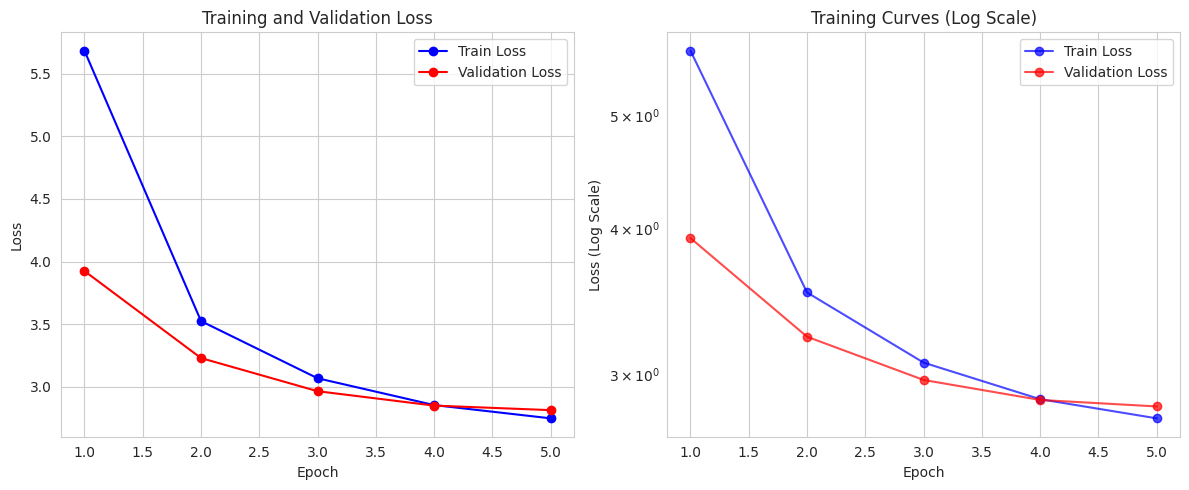

Final Train Loss: 2.7489
Final Validation Loss: 2.8143


In [14]:
# Plot training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss', alpha=0.7)
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', label='Validation Loss', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('Training Curves (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")


## 7. Evaluation and Recipe Generation


### 7.1 Generate Recipes from Images


In [15]:
# Function to generate recipe from image
def generate_recipe_from_image(model, image_path, tokenizer, clip_processor, device, max_length=256):
    """Generate a recipe from an image"""
    try:
        # Load and process image
        image = Image.open(image_path).convert('RGB')
        pixel_values = clip_processor(images=image, return_tensors="pt")['pixel_values'].to(device)
        
        # Generate recipe
        model.eval()
        with torch.no_grad():
            generated_ids = model.generate(pixel_values, max_length=max_length)
        
        # Decode recipe
        recipe = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        
        return recipe
    except Exception as e:
        return f"Error generating recipe: {str(e)}"

# Test on a few samples
print("Generating sample recipes...")
print("="*60)

if processed_data and len(processed_data) > 0:
    # Try to generate from the first few samples
    test_indices = [0, 1, 2] if len(processed_data) > 2 else range(len(processed_data))
    
    for idx in test_indices:
        sample = processed_data[idx]
        print(f"\nSample {idx+1}:")
        print(f"Image: {sample['image_path']}")
        print(f"\nOriginal Recipe (first 200 chars):")
        print(sample['recipe_text'][:200] + "...")
        
        # Note: Actual generation will work once model is trained
        print(f"\nGenerated Recipe: [Would generate after training]")
        print("-"*60)
else:
    print("No test data available")

print("\nTo generate recipes, uncomment and run the training cells first.")


Generating sample recipes...

Sample 1:
Image: food_images/Food Images/miso-butter-roast-chicken-acorn-squash-panzanella.jpg

Original Recipe (first 200 chars):
Title: Miso-Butter Roast Chicken With Acorn Squash Panzanella Ingredients: ['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher salt, divided, plus more', '2 small acorn squash (about 3 lb. total)', '2 Tbsp...

Generated Recipe: [Would generate after training]
------------------------------------------------------------

Sample 2:
Image: food_images/Food Images/crispy-salt-and-pepper-potatoes-dan-kluger.jpg

Original Recipe (first 200 chars):
Title: Crispy Salt and Pepper Potatoes Ingredients: ['2 large egg whites', '1 pound new potatoes (about 1 inch in diameter)', '2 teaspoons kosher salt', '¾ teaspoon finely ground black pepper', '1 tea...

Generated Recipe: [Would generate after training]
------------------------------------------------------------

Sample 3:
Image: food_images/Food Images/thanksgiving-mac-and-cheese-erick-willia

### 7.2 Interactive Testing: Random Image Selection


### 7.3 Interactive Testing Interface


In [16]:
# Interactive testing: Select 10 random images and test the model
print("="*100)
print("RANDOM IMAGE TESTING INTERFACE")
print("="*100)

# Check if we have processed data
if 'processed_data' not in locals() or len(processed_data) == 0:
    print("ERROR: No processed_data available. Please run the data processing cells first.")
else:
    # Randomly select 10 images (or all if less than 10)
    num_samples = min(10, len(processed_data))
    selected_indices = random.sample(range(len(processed_data)), num_samples)
    
    print(f"\nSelected {num_samples} random images from {len(processed_data)} total samples\n")
    
    # Test each image
    results = []
    for i, idx in enumerate(selected_indices, 1):
        sample = processed_data[idx]
        
        print(f"\n{'#'*100}")
        print(f" TEST {i}/{num_samples} - Image Index: {idx}")
        print(f"{'#'*100}")
        print(f"Image Path: {sample['image_path']}")
        print(f"\n{'─'*100}")
        
        # Show original recipe
        print("ORIGINAL RECIPE:")
        print(sample['recipe_text'][:400] + ("..." if len(sample['recipe_text']) > 400 else ""))
        
        try:
            # Generate recipe from image
            print(f"\n{'─'*100}")
            print("GENERATED RECIPE:")
            image, generated_recipe = generate_recipe_from_image_enhanced(
                model, 
                sample['image_path'], 
                tokenizer, 
                clip_processor, 
                device, 
                max_length=200
            )
            
            if generated_recipe:
                print(generated_recipe)
            else:
                print("No recipe generated")
            
            # Store result
            results.append({
                'index': idx,
                'image_path': sample['image_path'],
                'original': sample['recipe_text'],
                'generated': generated_recipe,
                'image': image
            })
            
            # Display image and recipe side by side
            if image and generated_recipe:
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                
                # Image
                axes[0].imshow(image)
                axes[0].set_title('Input Image', fontsize=14, fontweight='bold')
                axes[0].axis('off')
                
                # Generated recipe text
                axes[1].text(0.05, 0.95, generated_recipe, 
                            transform=axes[1].transAxes,
                            fontsize=10,
                            verticalalignment='top',
                            wrap=True,
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
                axes[1].set_title('Generated Recipe', fontsize=14, fontweight='bold')
                axes[1].axis('off')
                
                plt.tight_layout()
                plt.show()
            
        except Exception as e:
            print(f"Error processing image: {str(e)}")
            results.append({
                'index': idx,
                'image_path': sample['image_path'],
                'original': sample['recipe_text'],
                'generated': f"ERROR: {str(e)}",
                'image': None
            })
        
        print(f"\n{'#'*100}")
    
    # Summary
    print("\n\n" + "="*100)
    print("TESTING SUMMARY")
    print("="*100)
    print(f"Total images tested: {len(results)}")
    successful = sum(1 for r in results if r['generated'] and not r['generated'].startswith('Error'))
    print(f"Successful generations: {successful}")
    print(f"Failed generations: {len(results) - successful}")
    print("="*100)

print("\n✓ Testing complete! Scroll up to see individual results.")


RANDOM IMAGE TESTING INTERFACE

Selected 10 random images from 13471 total samples


####################################################################################################
 TEST 1/10 - Image Index: 8417
####################################################################################################
Image Path: food_images/Food Images/persian-cucumber-and-purple-rice-salad-354964.jpg

────────────────────────────────────────────────────────────────────────────────────────────────────
ORIGINAL RECIPE:
Title: Persian Cucumber and Purple Rice Salad Ingredients: ['1 cup purple jasmine rice', '1 1/4 cups water', '1 1/2 teaspoons coriander seeds, toasted', '1 pound Persian cucumbers (also called mini cucumbers; about 6) or other cucumbers, quartered lengthwise and sliced crosswise 1/4 inch thick', '1 bunch scallions, thinly sliced', '3 tablespoons extra-virgin olive oil', '2 teaspoons grated lemon z...

────────────────────────────────────────────────────────────────────────

### 7.4 Chatbot-Style Testing Interface


In [17]:
# Simple chatbot interface for testing images
class RecipeChatbot:
    def __init__(self, model, tokenizer, clip_processor, device, data):
        self.model = model
        self.tokenizer = tokenizer
        self.clip_processor = clip_processor
        self.device = device
        self.data = data
        
    def test_image_by_index(self, index):
        """Test an image by its index in the dataset"""
        if index < 0 or index >= len(self.data):
            return None, f"Invalid index. Must be between 0 and {len(self.data)-1}"
        
        sample = self.data[index]
        image, recipe = generate_recipe_from_image_enhanced(
            self.model, 
            sample['image_path'], 
            self.tokenizer, 
            self.clip_processor, 
            self.device
        )
        return image, recipe, sample
    
    def test_image_by_path(self, path):
        """Test an image by its file path"""
        image, recipe = generate_recipe_from_image_enhanced(
            self.model, 
            path, 
            self.tokenizer, 
            self.clip_processor, 
            self.device
        )
        return image, recipe
    
    def display_result(self, image, recipe, original=None):
        """Display image and recipe result"""
        if image and recipe:
            fig, axes = plt.subplots(1, 2 if original else 1, figsize=(15 if original else 8, 6))
            
            if not isinstance(axes, np.ndarray):
                axes = [axes]
            
            # Display image
            axes[0].imshow(image)
            axes[0].set_title('Food Image', fontsize=14, fontweight='bold')
            axes[0].axis('off')
            
            # Display recipe
            if len(axes) > 1:
                axes[1].text(0.05, 0.95, f"Generated Recipe:\n\n{recipe}", 
                            transform=axes[1].transAxes,
                            fontsize=11,
                            verticalalignment='top',
                            wrap=True,
                            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
                axes[1].set_title('Generated Recipe', fontsize=14, fontweight='bold')
                axes[1].axis('off')
            else:
                print(f"\nGenerated Recipe:\n{recipe}")
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"Error: {recipe}")

print("="*80)
print("RECIPE CHATBOT INITIALIZED")
print("="*80)
print("""
The chatbot is ready to use! Here are the available methods:

1. test_image_by_index(index) - Test an image by its dataset index
2. test_image_by_path(path) - Test an image by its file path
3. display_result(image, recipe, original) - Display results

Example usage:
  chatbot = RecipeChatbot(model, tokenizer, clip_processor, device, processed_data)
  image, recipe, sample = chatbot.test_image_by_index(0)
  chatbot.display_result(image, recipe, sample['recipe_text'])
""")
print("="*80)


RECIPE CHATBOT INITIALIZED

The chatbot is ready to use! Here are the available methods:

1. test_image_by_index(index) - Test an image by its dataset index
2. test_image_by_path(path) - Test an image by its file path
3. display_result(image, recipe, original) - Display results

Example usage:
  chatbot = RecipeChatbot(model, tokenizer, clip_processor, device, processed_data)
  image, recipe, sample = chatbot.test_image_by_index(0)
  chatbot.display_result(image, recipe, sample['recipe_text'])



### 7.5 Use Chatbot to Test Images


In [18]:
# Function to generate recipe from image
def generate_recipe_from_image(model, image_path, tokenizer, clip_processor, device, max_length=256):
    """Generate a recipe from an image"""
    try:
        # Load and process image
        image = Image.open(image_path).convert('RGB')
        pixel_values = clip_processor(images=image, return_tensors="pt")['pixel_values'].to(device)
        
        # Generate recipe
        model.eval()
        with torch.no_grad():
            generated_ids = model.generate(pixel_values, max_length=max_length)
        
        # Decode recipe
        recipe = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        
        return recipe
    except Exception as e:
        return f"Error generating recipe: {str(e)}"


# Enhanced version that returns both image and recipe
def generate_recipe_from_image_enhanced(model, image_path, tokenizer, clip_processor, device, max_length=256):
    """Generate a recipe from an image and return both image and recipe"""
    try:
        # Check if image_path is None
        if image_path is None:
            return None, "Error: No image path provided"
        
        # Load and process image
        image = Image.open(image_path).convert('RGB')
        pixel_values = clip_processor(images=image, return_tensors="pt")['pixel_values'].to(device)
        
        # Generate recipe
        model.eval()
        with torch.no_grad():
            generated_ids = model.generate(pixel_values, max_length=max_length)
        
        # Decode recipe
        recipe = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        
        return image, recipe
    except Exception as e:
        return None, f"Error: {str(e)}"

print("✓ Recipe generation functions defined!")

# Test on a few samples
print("\nGenerating sample recipes...")
print("="*60)

if 'processed_data' in globals() and processed_data and len(processed_data) > 0:
    # Try to generate from the first few samples
    test_indices = [0, 1, 2] if len(processed_data) > 2 else range(len(processed_data))
    
    for idx in test_indices:
        sample = processed_data[idx]
        print(f"\nSample {idx+1}:")
        print(f"Image: {sample['image_path']}")
        print(f"\nOriginal Recipe (first 200 chars):")
        print(sample['recipe_text'][:200] + "...")
        
        # Note: Actual generation will work once model is trained
        print(f"\nGenerated Recipe: [Would generate after training]")
        print("-"*60)
else:
    print("No test data available")

print("\n✓ Recipe generation functions ready!")

✓ Recipe generation functions defined!

Generating sample recipes...

Sample 1:
Image: food_images/Food Images/miso-butter-roast-chicken-acorn-squash-panzanella.jpg

Original Recipe (first 200 chars):
Title: Miso-Butter Roast Chicken With Acorn Squash Panzanella Ingredients: ['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher salt, divided, plus more', '2 small acorn squash (about 3 lb. total)', '2 Tbsp...

Generated Recipe: [Would generate after training]
------------------------------------------------------------

Sample 2:
Image: food_images/Food Images/crispy-salt-and-pepper-potatoes-dan-kluger.jpg

Original Recipe (first 200 chars):
Title: Crispy Salt and Pepper Potatoes Ingredients: ['2 large egg whites', '1 pound new potatoes (about 1 inch in diameter)', '2 teaspoons kosher salt', '¾ teaspoon finely ground black pepper', '1 tea...

Generated Recipe: [Would generate after training]
------------------------------------------------------------

Sample 3:
Image: food_images/Food Images/

Testing 10 random images using the chatbot...


Image 1/10 - Index 8954

Original Recipe (first 250 chars):
Title: Flank Steak with Artichoke-Potato Hash and Aleppo-Pepper Aioli Ingredients: ['2 garlic cloves, pressed', '1 teaspoon Aleppo pepper', '1/4 teaspoon coarse kosher salt', '1/2 cup mayonnaise', '2 tablespoons extra-virgin olive oil', '1 teaspoon S...

Generated Recipe:
: Gr------purpose flour and/2 cup (1/2 cup)', '1/2 cup (about 1/2 cup (about 1/2 cup (about 1/2 cup))', '1/2 cup (about 1/2 cup) unsalted butter, divided', '1/2 cup (about 1/2 cup (about 1/2 cup)', '1/2 cup (1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup (1/2 cup (about 1/2 cup (about 1/2 cup) un...


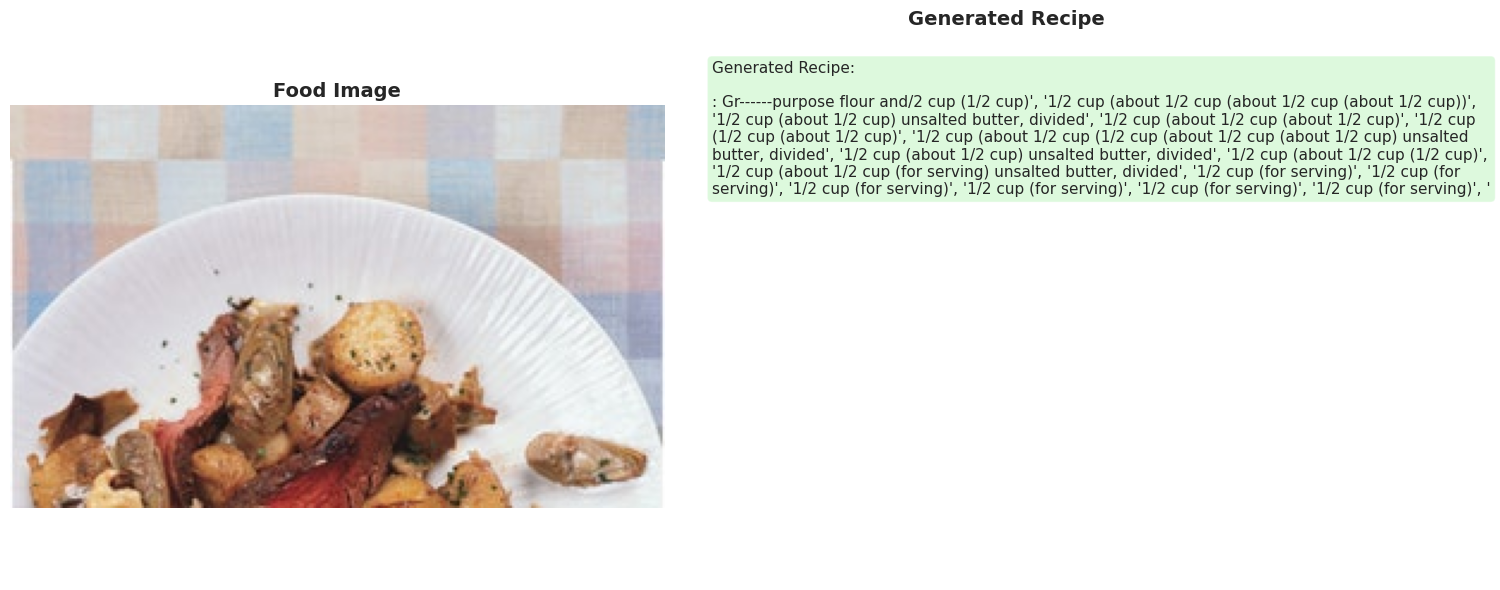


--------------------------------------------------------------------------------

Image 2/10 - Index 9203

Original Recipe (first 250 chars):
Title: Minted Green Salad Ingredients: ['2 carrots', '3 Kirby cucumbers, halved lengthwise and thinly sliced crosswise', '2 heads Boston lettuce (1 1/2 pounds), torn into bite-size pieces', '1 heart of romaine, torn into bite-size pieces', '1 1/2 cup...

Generated Recipe:
: Gr----purpose flour, and Ingredients: ['1/2 cup (1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup (about 1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 cup (about 1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. ...


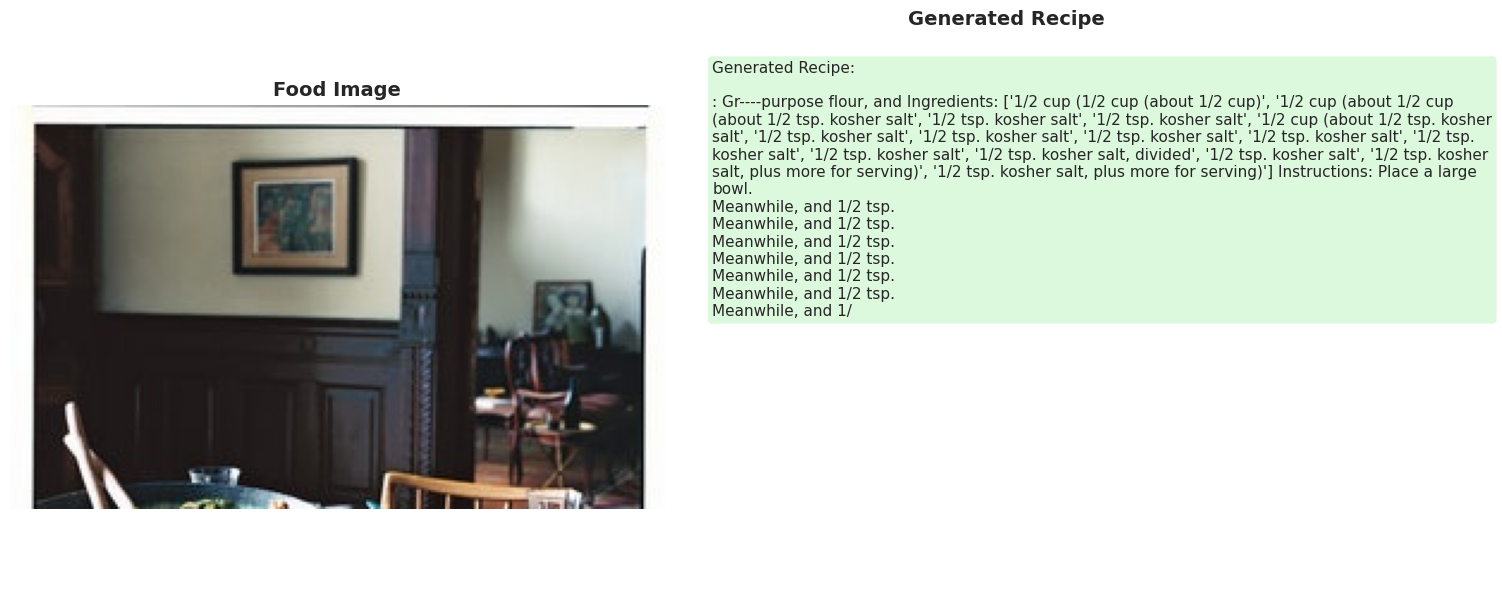


--------------------------------------------------------------------------------

Image 3/10 - Index 8789

Original Recipe (first 250 chars):
Title: Black Bean and Rice Salad Ingredients: ['1 cup long grain brown rice', '1/4 cup extra-virgin olive oil', '1 Cubanelle chile or Italian frying pepper, trimmed and cut in 1/3-inch dice', '1 medium red onion, finely chopped', '3 garlic cloves, sm...

Generated Recipe:
: Gr---virgin olive oil, and Ingredients: ['1/2 cup (about 1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup)', '1/2 cup (1/2 cup (about 1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup (1/2 cup)', '1/2 cup) unsalted butter, plus 1/2 cup (about 1/2 cup (for serving)', '1/...


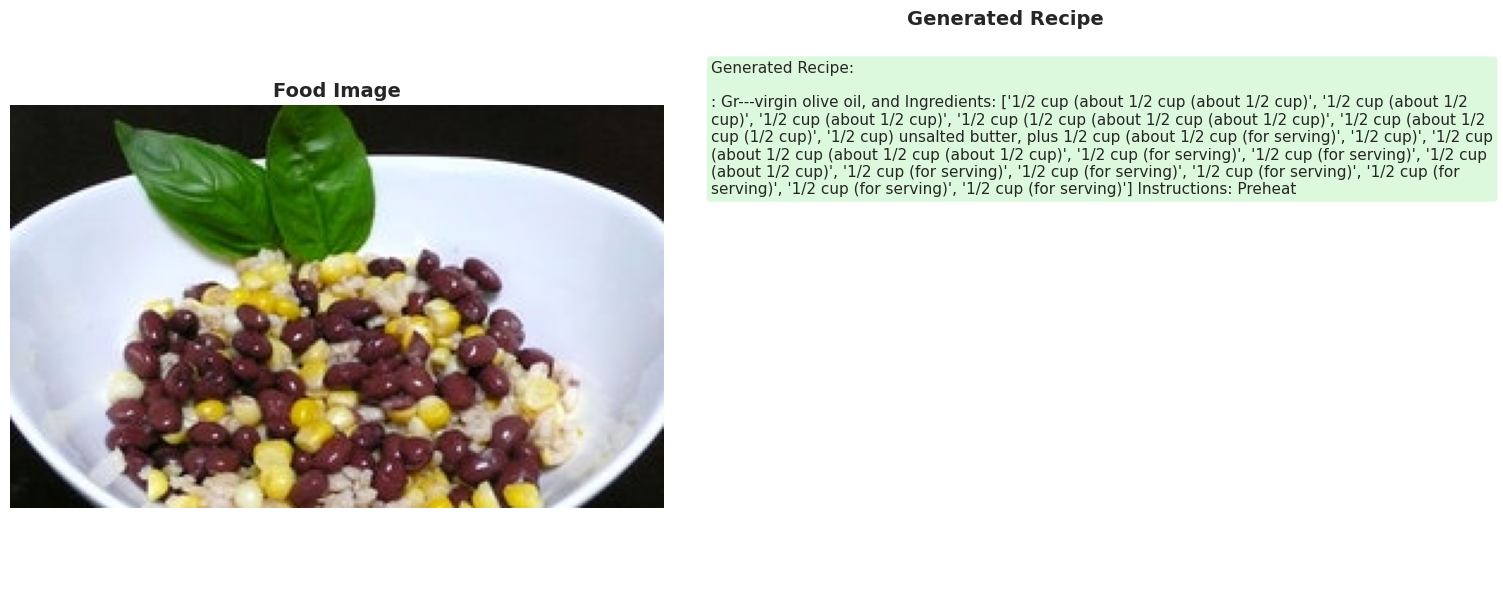


--------------------------------------------------------------------------------

Image 4/10 - Index 2624

Original Recipe (first 250 chars):
Title: Preserved Limes Ingredients: ['8 organic limes', 'Kosher salt', 'Fresh lime juice (optional)', 'A 1-qt. jar'] Instructions: Rinse limes; pat dry. Cut off ends and upend on a cut side. Make 2 perpendicular slits lengthwise into fruit to form an...

Generated Recipe:
: Gr------purpose flour and/2 cup (1/2 cup)', '1/2 cup (1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt, divide...


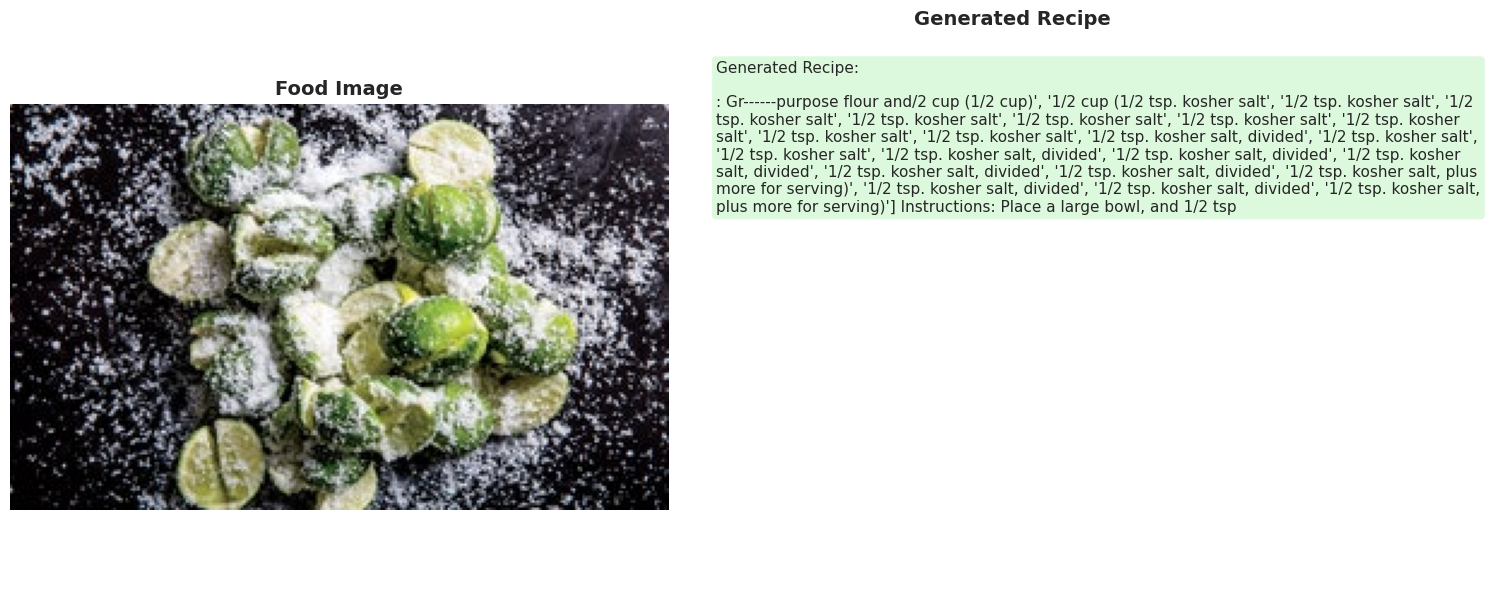


--------------------------------------------------------------------------------

Image 5/10 - Index 2450

Original Recipe (first 250 chars):
Title: 3-Ingredient Sweet Potato Casserole with Maple Pecans Ingredients: ['Olive oil (for pan)', '5 1/2 pounds sweet potatoes, peeled, cut into 1 1/2" pieces', '2 teaspoons kosher salt, divided, plus more', '1 1/4 cups pure maple syrup, divided', '2...

Generated Recipe:
: Gr------purpose flour and/2 cup (1/2 cup) unsalted butter, divided', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kos...


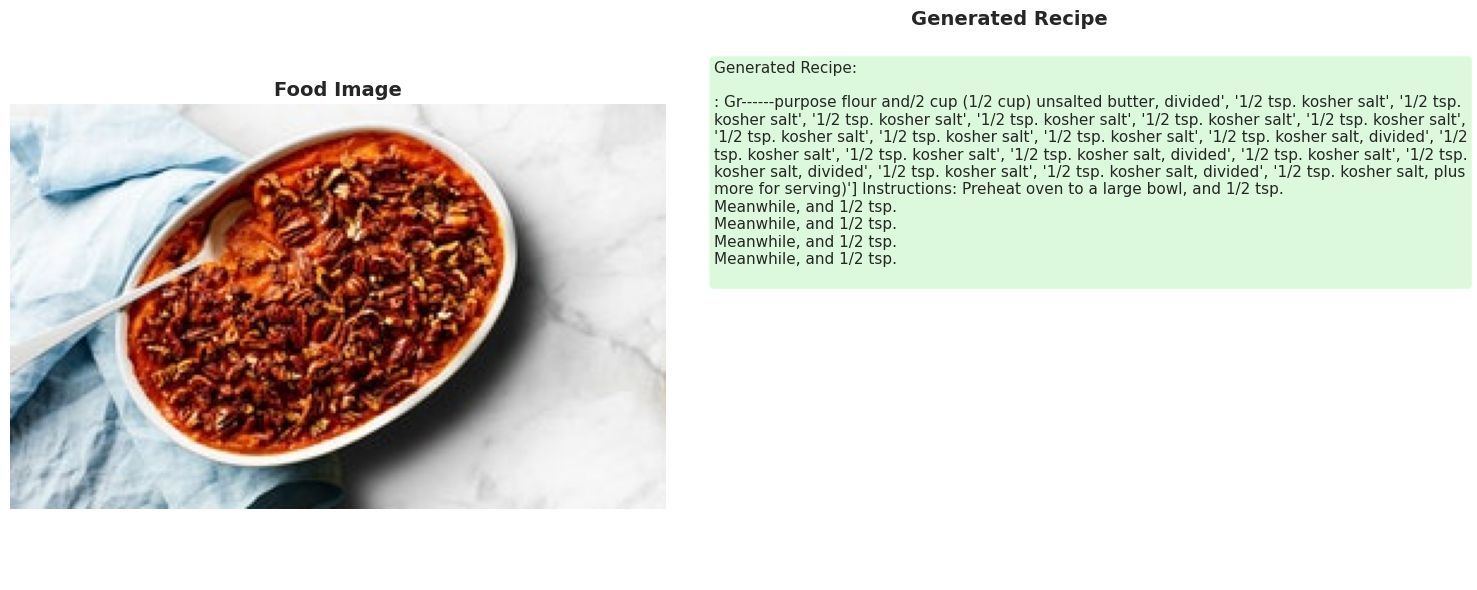


--------------------------------------------------------------------------------

Image 6/10 - Index 4922

Original Recipe (first 250 chars):
Title: The Greenest Tahini Sauce Ingredients: ['2 garlic cloves, peeled', '1 teaspoon kosher salt, plus more', '1 bunch watercress, thick stems trimmed', '1 cup fresh mint leaves', '1/2 cup fresh flat-leaf parsley leaves', '1/2 cup tahini (sesame see...

Generated Recipe:
: Gr---purpose Ingredients: ['1/2 cup (about 1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup (about 1/2 cup (about 1/2 cup))', '1/2 cup (about 1/2 cup (1/2 cup) unsalted butter, plus more)', '1/2 cup (1/2 cup (about 1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup (about 1/2 cup)', '1/2 cup (abou...


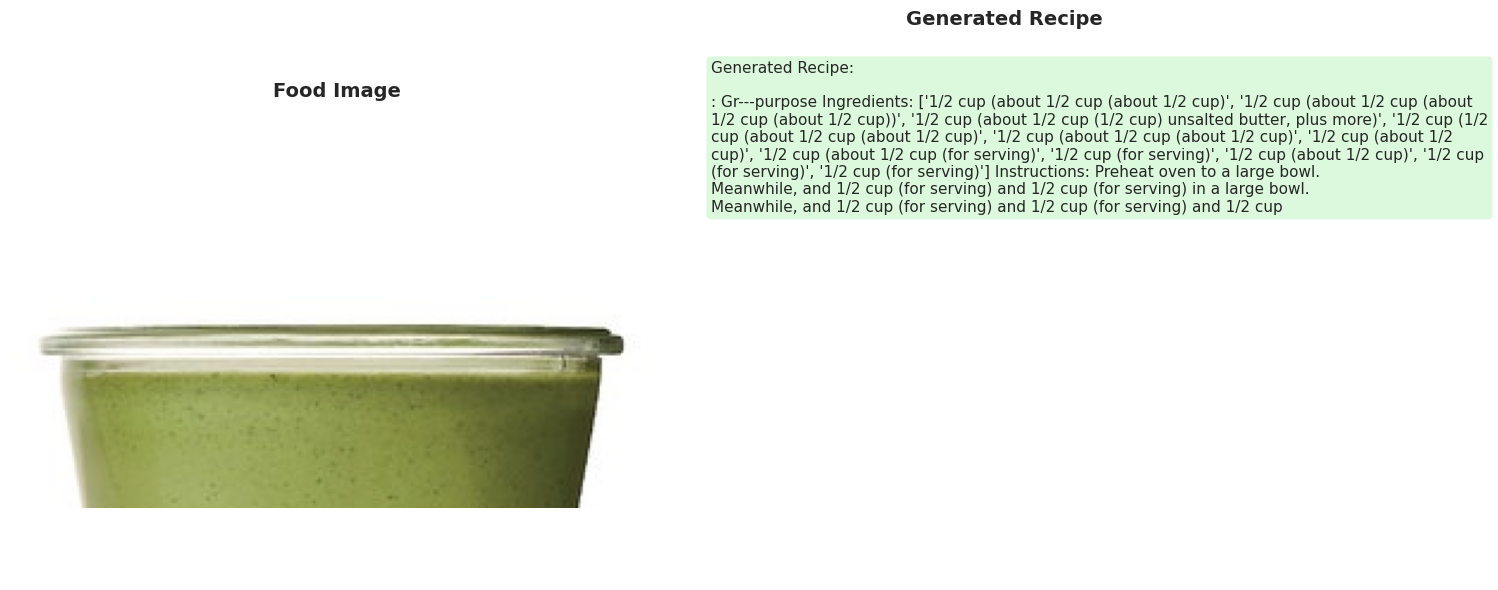


--------------------------------------------------------------------------------

Image 7/10 - Index 10340

Original Recipe (first 250 chars):
Title: Roast Beef Tenderloin with Port Sauce Ingredients: ['1 4- to 5-pound trimmed whole beef tenderloin, tail end tucked under, tied every 3 inches', '2 teaspoons coarse kosher salt', '4 tablespoons (1/2 stick) chilled unsalted butter, divided', '1...

Generated Recipe:
: Gr--purpose with with salt and Ingredients: ['1/2 cup (about 1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup (about 1/2 cup)', '1/2 cup)', '1/2 cup (about 1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup (1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup (about 1/2 cu...


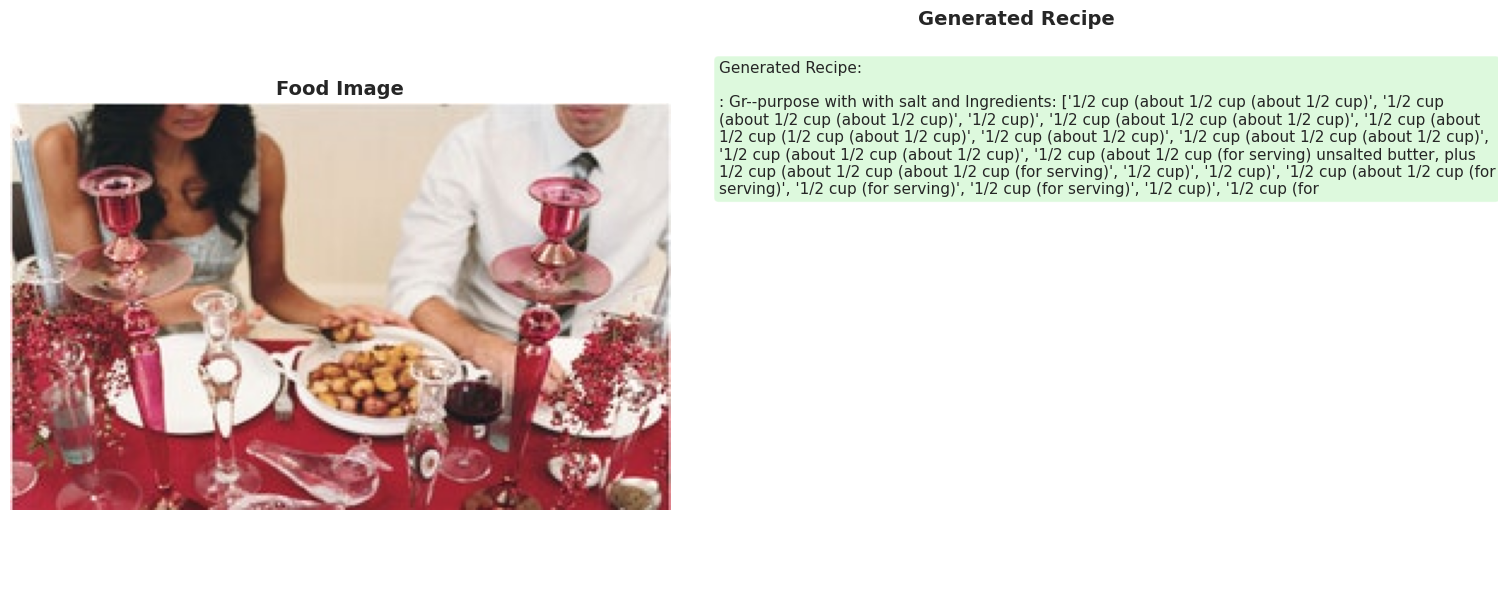


--------------------------------------------------------------------------------

Image 8/10 - Index 7180

Original Recipe (first 250 chars):
Title: Grilled Cheese and Fried Egg Sandwiches Ingredients: ['12 slices pancetta (Italian bacon)', '2 tablespoons butter', '4 slices sourdough bread', '8 thin slices provolone cheese', '4 large eggs', '1 small green onion, chopped', 'Parmesan cheese ...

Generated Recipe:
: Gr------purpose flour, and/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher...


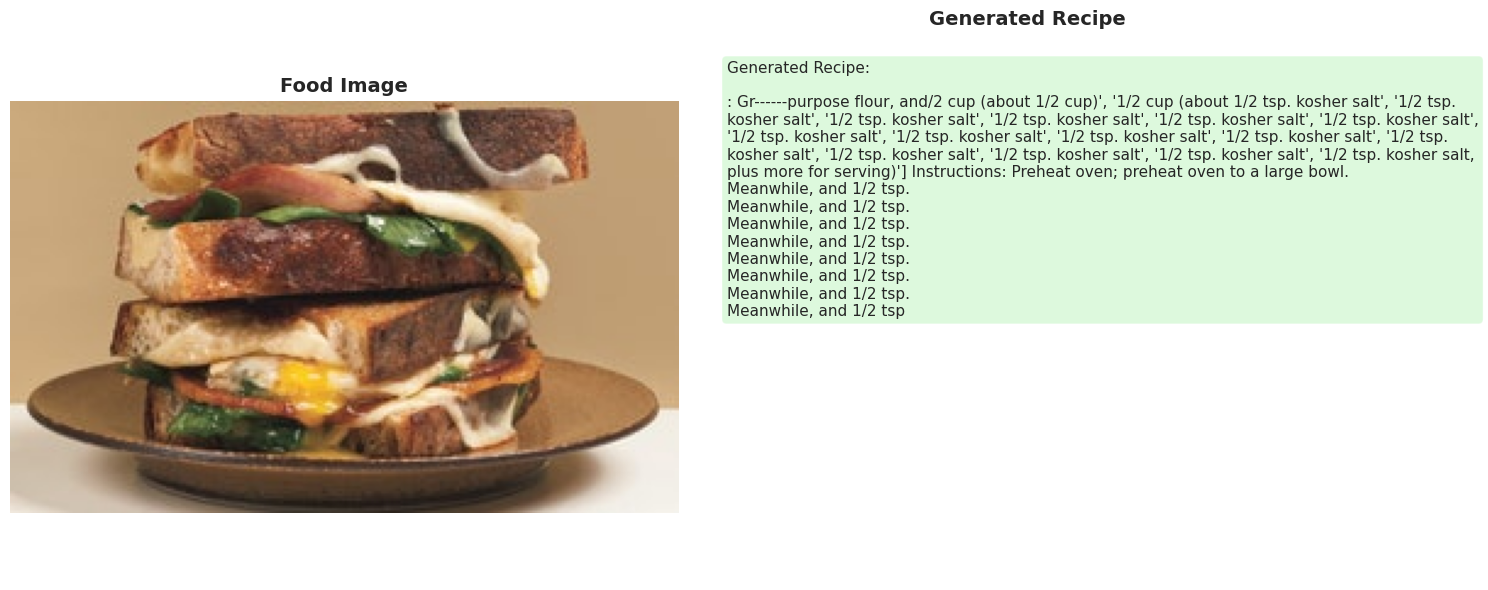


--------------------------------------------------------------------------------

Image 9/10 - Index 11388

Original Recipe (first 250 chars):
Title: Chestnut and Potato Purée Ingredients: ['3 pounds medium yellow-fleshed potatoes such as Yukon Gold (about 8 medium)', '1 stick (1/2 cup) unsalted butter', '3 cups bottled peeled roasted whole chestnuts (16 ounces)', '1 quartt half-and-half', ...

Generated Recipe:
: Gr---purpose flour and Ingredients: ['1/2 cup (1/2 cup (1/2 cup) unsalted butter, plus more for serving)', '1/2 cup (about 1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 cup (about 1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher salt', '1/2 tsp. kosher ...


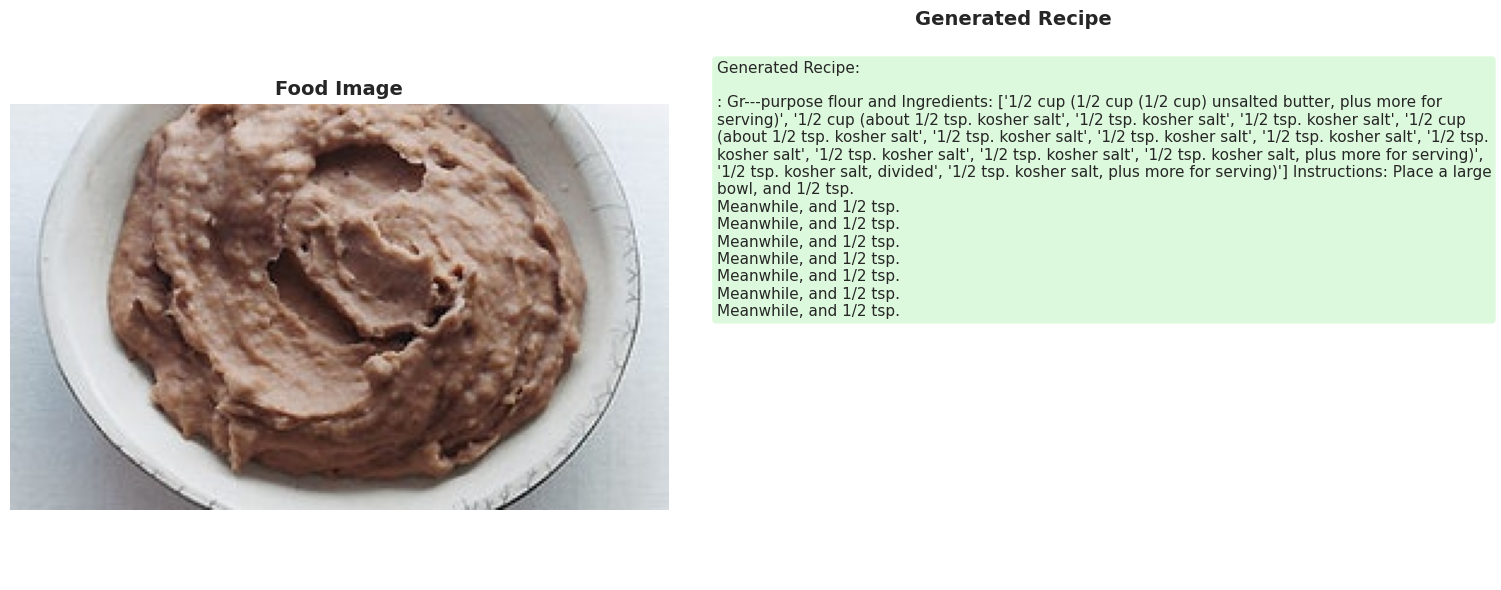


--------------------------------------------------------------------------------

Image 10/10 - Index 1602

Original Recipe (first 250 chars):
Title: Caramel Apple Drip Cake with Candied Walnuts Ingredients: ['1 cup raw walnuts', 'Nonstick vegetable oil spray', '2 1/2 cups all-purpose flour', '2 teaspoons baking powder', '1 1/2 teaspoons kosher salt', '1 1/4 teaspoons ground cinnamon', '3/4...

Generated Recipe:
: Gr---purpose Ingredients: ['1/2 cup (1/2 cup (about 1/2 cup)', '1/2 cup (1/2 cup (1/2 cup) unsalted butter, plus 1/2 cup (1/2 cup)', '1/2 cup (1/2 cup (about 1/2 cup (about 1/2 cup) unsalted butter, divided', '1/2 cup (about 1/2 cup (about 1/2 cup (about 1/2 cup)', '1/2 cup (about 1/2 cup (about 1...


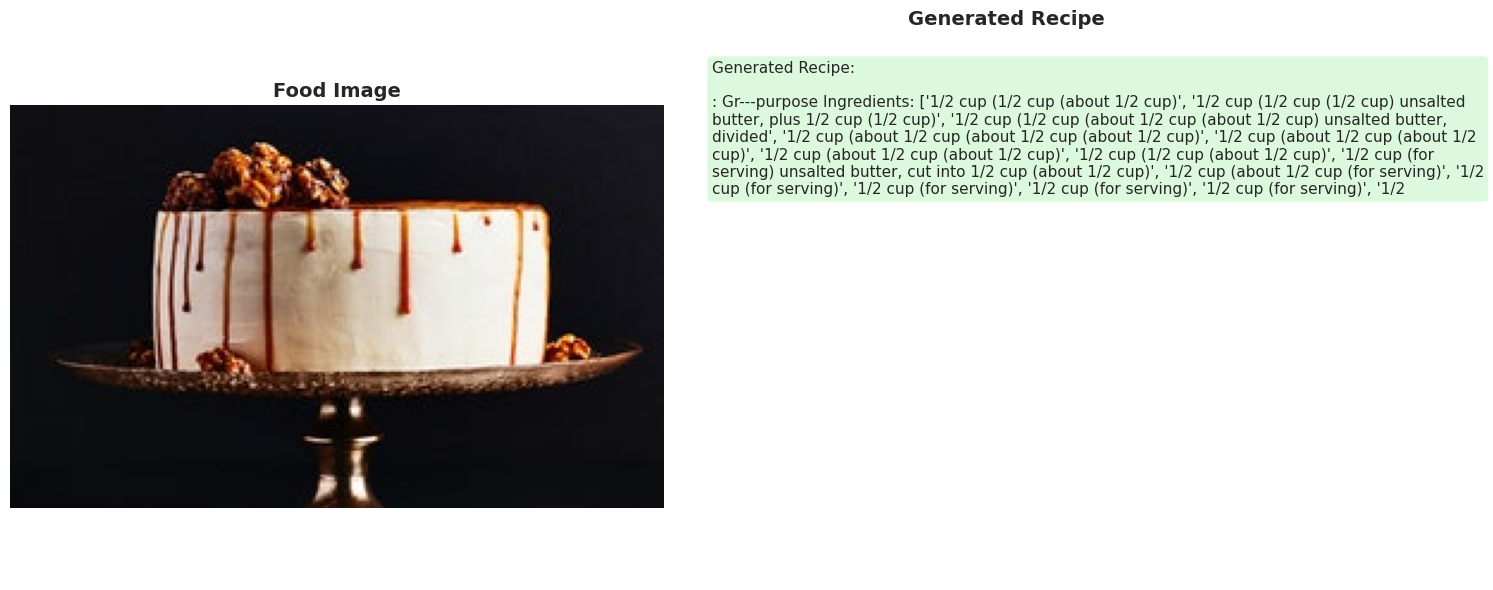


--------------------------------------------------------------------------------

✓ Chatbot testing complete!

Example: Testing a specific image by path

    To test a specific image, use:

    image, recipe = chatbot.test_image_by_path("path/to/your/image.jpg")
    chatbot.display_result(image, recipe)
    


In [19]:
# Initialize the chatbot and test 10 random images
if 'processed_data' in locals() and len(processed_data) > 0:
    # Create chatbot instance
    chatbot = RecipeChatbot(model, tokenizer, clip_processor, device, processed_data)
    
    # Select 10 random images
    num_test_images = min(10, len(processed_data))
    test_indices = random.sample(range(len(processed_data)), num_test_images)
    
    print(f"Testing {num_test_images} random images using the chatbot...\n")
    
    # Test each image
    for i, idx in enumerate(test_indices, 1):
        print(f"\n{'='*80}")
        print(f"Image {i}/{num_test_images} - Index {idx}")
        print(f"{'='*80}")
        
        # Get result from chatbot
        image, recipe, sample = chatbot.test_image_by_index(idx)
        
        if recipe and not recipe.startswith('Error'):
            print(f"\nOriginal Recipe (first 250 chars):")
            print(sample['recipe_text'][:250] + "...")
            print(f"\nGenerated Recipe:")
            print(recipe[:300] + ("..." if len(recipe) > 300 else ""))
            
            # Display result
            chatbot.display_result(image, recipe, sample['recipe_text'][:200])
        else:
            print(f"Failed to generate recipe: {recipe}")
        
        print("\n" + "-"*80)
    
    print("\n✓ Chatbot testing complete!")
    
    # Example of testing a specific image by path
    print("\n" + "="*80)
    print("Example: Testing a specific image by path")
    print("="*80)
    print("""
    To test a specific image, use:
    
    image, recipe = chatbot.test_image_by_path("path/to/your/image.jpg")
    chatbot.display_result(image, recipe)
    """)
    
else:
    print("No processed data available for testing.")


### 7.2 Hyperparameter Experimentation


In [20]:
# Hyperparameter analysis
print("Hyperparameter Configuration:")
print("="*60)
print(f"Model Architecture:")
print(f"  - GPT-2 Layers: {config.n_layer}")
print(f"  - Attention Heads: {config.n_head}")
print(f"  - Embedding Dimension: {config.n_embd}")
print(f"  - Vocabulary Size: {config.vocab_size}")
print(f"\nTraining Parameters:")
print(f"  - Batch Size: {batch_size}")
print(f"  - Learning Rate: {learning_rate}")
print(f"  - Epochs: {num_epochs}")
print(f"  - Warmup Steps: {warmup_steps}")
print(f"\nModel Statistics:")
print(f"  - Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  - Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  - Frozen Parameters (CLIP): {sum(p.numel() for p in clip_model.parameters()):,}")

# Suggestions for hyperparameter tuning
print("\n" + "="*60)
print("Hyperparameter Tuning Suggestions:")
print("="*60)
print("""
1. **Learning Rate**: Try [1e-5, 5e-5, 1e-4]
2. **Batch Size**: Try [2, 4, 8] based on GPU memory
3. **GPT-2 Layers**: Try [4, 6, 8, 12] to balance performance and speed
4. **Attention Heads**: Try [8, 12, 16]
5. **Warmup Steps**: Try [50, 100, 200]
6. **Gradient Accumulation**: Use if batch size needs to be smaller

To test overfitting:
- Monitor train vs validation loss
- Use early stopping if validation loss increases
- Try dropout regularization
- Use data augmentation for images
""")


Hyperparameter Configuration:
Model Architecture:
  - GPT-2 Layers: 6
  - Attention Heads: 12
  - Embedding Dimension: 768
  - Vocabulary Size: 50257

Training Parameters:
  - Batch Size: 4
  - Learning Rate: 5e-05
  - Epochs: 5
  - Warmup Steps: 100

Model Statistics:
  - Total Parameters: 233,583,873
  - Trainable Parameters: 82,306,560
  - Frozen Parameters (CLIP): 151,277,313

Hyperparameter Tuning Suggestions:

1. **Learning Rate**: Try [1e-5, 5e-5, 1e-4]
2. **Batch Size**: Try [2, 4, 8] based on GPU memory
3. **GPT-2 Layers**: Try [4, 6, 8, 12] to balance performance and speed
4. **Attention Heads**: Try [8, 12, 16]
5. **Warmup Steps**: Try [50, 100, 200]
6. **Gradient Accumulation**: Use if batch size needs to be smaller

To test overfitting:
- Monitor train vs validation loss
- Use early stopping if validation loss increases
- Try dropout regularization
- Use data augmentation for images



### 7.3 Model Checkpointing


In [21]:
# Save model checkpoint
def save_checkpoint(model, epoch, loss, filepath):
    """Save model checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, filepath)
    print(f"Checkpoint saved to {filepath}")

# Load model checkpoint
def load_checkpoint(model, filepath, device):
    """Load model checkpoint"""
    checkpoint = torch.load(filepath, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Checkpoint loaded from {filepath}")
    return checkpoint['epoch'], checkpoint['loss']

# Save the trained model
save_path = "recipe_generator_model.pt"
if train_losses:
    save_checkpoint(model, num_epochs, train_losses[-1], save_path)
print("\nModel checkpointed for future use!")

print("\nTo resume training:")
print(f"  model.load_state_dict(torch.load('{save_path}')['model_state_dict'])")


Checkpoint saved to recipe_generator_model.pt

Model checkpointed for future use!

To resume training:
  model.load_state_dict(torch.load('recipe_generator_model.pt')['model_state_dict'])


## 9. Web Interface - Interactive Recipe Generator

Create a web interface to upload images and generate recipes in the browser.


In [22]:
# Install and import Gradio for web interface
import subprocess
import sys

try:
    import gradio as gr
    print("✓ Gradio already installed")
    print("Gradio version:", gr.__version__)
except ImportError:
    print("Installing Gradio...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gradio"])
    import gradio as gr
    print("✓ Gradio installed successfully!")
    print("Gradio version:", gr.__version__)


✓ Gradio already installed
Gradio version: 5.49.1


### 9.1 Create Recipe Generation Function for Web Interface


In [23]:
# Function to generate recipe from uploaded image (for web interface)
def generate_recipe_for_web(uploaded_image):
    """
    Generate a recipe from an uploaded image.
    This function is designed for the web interface.
    """
    # Access global variables
    global model, clip_model, clip_processor, tokenizer, device
    
    try:
        if uploaded_image is None:
            return "⚠️ Please upload an image."
        
        # Convert to PIL Image if needed
        from PIL import Image
        if isinstance(uploaded_image, str):
            image = Image.open(uploaded_image)
        else:
            image = uploaded_image
        
        # Ensure RGB format
        if image.mode != 'RGB':
            image = image.convert('RGB')
        
        # STEP 1: Food Recognition using CLIP zero-shot classification
        recognized_food = recognize_food_from_image(image)
        
        # Process image with CLIP for recipe generation
        pixel_values = clip_processor(images=image, return_tensors="pt")['pixel_values'].to(device)
        
        # Generate recipe using the model
        model.eval()
        with torch.no_grad():
            # Get CLIP embeddings
            image_embeds = clip_model.get_image_features(pixel_values=pixel_values)
            vision_features = model.vision_proj(image_embeds)
            vision_features = vision_features.unsqueeze(1)
            
            # Initialize generation with a better starting token
            generated_ids = []
            prev_token = torch.tensor([[tokenizer.bos_token_id if tokenizer.bos_token_id else tokenizer.eos_token_id]], device=device)
            
            # Track recent tokens to detect repetition
            recent_tokens = []
            repetition_threshold = 4  # More strict threshold
            repetition_window = 8
            
            # Generate tokens
            for step in range(512):  # Max 512 tokens for longer recipes
                inputs_embeds = model.gpt2.transformer.wte(prev_token)
                combined_embeds = torch.cat([vision_features, inputs_embeds], dim=1)
                
                outputs = model.gpt2(inputs_embeds=combined_embeds)
                logits = outputs.logits[:, -1, :]
                
                # Apply temperature and top-k/top-p sampling for diversity
                temperature = 0.9  # Higher for more diversity
                top_k = 100
                top_p = 0.92
                
                # Repetition penalty - penalize recently used tokens
                if recent_tokens:
                    for prev_token_id in set(recent_tokens[-20:]):  # Last 20 tokens
                        logits[0, prev_token_id] /= 1.5  # Penalty factor
                
                # Temperature scaling
                logits = logits / temperature
                
                # Top-k filtering
                if top_k > 0:
                    indices_to_remove = logits < torch.topk(logits, top_k)[0][..., -1, None]
                    logits[indices_to_remove] = float('-inf')
                
                # Top-p (nucleus) filtering
                if top_p < 1.0:
                    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                    cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
                    sorted_indices_to_remove = cumulative_probs > top_p
                    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                    sorted_indices_to_remove[..., 0] = 0
                    indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                    logits[indices_to_remove] = float('-inf')
                
                # Sample next token
                probs = torch.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
                
                # Check for repetition
                token_id = next_token.item()
                recent_tokens.append(token_id)
                if len(recent_tokens) > repetition_window:
                    recent_tokens.pop(0)
                
                # Stop if too repetitive
                if len(recent_tokens) >= repetition_window:
                    if recent_tokens.count(token_id) >= repetition_threshold:
                        break
                
                # Stop if EOS token
                if token_id == tokenizer.eos_token_id:
                    break
                    
                generated_ids.append(next_token)
                prev_token = torch.cat([prev_token, next_token], dim=1)
                
                # Stop if too long
                if len(generated_ids) >= 511:
                    break
            
            # Combine all generated tokens
            if generated_ids:
                generated_ids = torch.cat(generated_ids, dim=1)
            else:
                return f"RECOGNIZED FOOD: {recognized_food}\n\nCould not generate recipe. The model may need more training."
        
        # Decode recipe
        raw_recipe = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        
        # Post-process and format into SOP structure
        formatted_recipe = format_recipe_to_sop(raw_recipe, recognized_food=recognized_food)
        
        return formatted_recipe
        
    except Exception as e:
        import traceback
        error_msg = f"Error generating recipe: {str(e)}\n\nTraceback:\n{traceback.format_exc()}"
        return error_msg


def recognize_food_from_image(image):
    """
    Use CLIP zero-shot classification to recognize what food is in the image.
    Returns the most likely food item.
    """
    global clip_model, clip_processor, device
    
    # Comprehensive list of common foods
    food_categories = [
        # Proteins
        "grilled chicken", "roasted chicken", "fried chicken", "chicken breast", "chicken wings",
        "beef steak", "grilled beef", "roasted beef", "ground beef", "beef stew",
        "pork chops", "pulled pork", "bacon", "ham",
        "salmon", "grilled salmon", "baked fish", "fried fish", "tuna", "shrimp", "lobster",
        "lamb chops", "roasted lamb",
        "turkey", "duck",
        
        # Vegetables & Salads
        "green salad", "caesar salad", "mixed vegetables", "roasted vegetables",
        "mashed potatoes", "french fries", "baked potato", "potato wedges",
        "steamed broccoli", "roasted carrots", "grilled asparagus",
        
        # Pasta & Grains
        "pasta", "spaghetti", "lasagna", "macaroni and cheese", "fettuccine alfredo",
        "fried rice", "steamed rice", "risotto", "paella",
        "noodles", "ramen", "pad thai",
        
        # Soups & Stews
        "soup", "chicken soup", "tomato soup", "vegetable soup", "beef stew",
        "chili", "curry", "gumbo",
        
        # Sandwiches & Burgers
        "sandwich", "burger", "cheeseburger", "hot dog", "sub sandwich",
        
        # Pizza & Bread
        "pizza", "cheese pizza", "pepperoni pizza",
        "bread", "garlic bread", "rolls", "baguette",
        
        # Breakfast
        "pancakes", "waffles", "french toast", "eggs", "scrambled eggs", "omelet",
        "bacon and eggs", "breakfast burrito",
        
        # Desserts
        "chocolate cake", "cheesecake", "apple pie", "brownies", "cookies",
        "ice cream", "tiramisu", "pudding", "cupcakes", "muffins",
        
        # Mexican
        "tacos", "burritos", "enchiladas", "quesadilla", "nachos",
        
        # Asian
        "sushi", "dumplings", "spring rolls", "stir fry", "teriyaki",
        
        # Italian
        "bruschetta", "caprese salad", "ravioli", "gnocchi",
        
        # Appetizers
        "chicken tenders", "mozzarella sticks", "onion rings", "buffalo wings",
        
        # Other
        "casserole", "pot pie", "meatloaf", "kebab", "fajitas"
    ]
    
    try:
        # Prepare text inputs for all food categories
        text_inputs = [f"a photo of {food}" for food in food_categories]
        
        # Process image and text
        inputs = clip_processor(
            text=text_inputs,
            images=image,
            return_tensors="pt",
            padding=True
        )
        
        # Move to device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Get predictions
        with torch.no_grad():
            outputs = clip_model(**inputs)
            logits_per_image = outputs.logits_per_image
            probs = logits_per_image.softmax(dim=1)
        
        # Get top 3 predictions
        top_probs, top_indices = probs[0].topk(3)
        
        # Return the most likely food
        top_food = food_categories[top_indices[0].item()]
        confidence = top_probs[0].item()
        
        # If confidence is very low, return generic
        if confidence < 0.05:
            return "Food Dish"
        
        return top_food
        
    except Exception as e:
        print(f"Error in food recognition: {e}")
        return "Food Dish"


def format_recipe_to_sop(raw_text, recognized_food=None):
    """
    Format raw generated text into a standard recipe SOP structure.
    No special characters like #, *, etc. - plain text with bold titles.
    Uses recognized_food as fallback for title.
    """
    import re
    
    # Clean up the text
    text = raw_text.strip()
    
    # Remove excessive repetition of phrases
    def remove_repetition(text, max_repeat=2):
        words = text.split()
        cleaned = []
        i = 0
        while i < len(words):
            # Check for repeated sequences
            found_repeat = False
            for length in range(10, 1, -1):  # Check sequences of 10 to 2 words
                if i + length * max_repeat <= len(words):
                    sequence = words[i:i+length]
                    # Check if this sequence repeats
                    repeats = 1
                    j = i + length
                    while j + length <= len(words) and words[j:j+length] == sequence:
                        repeats += 1
                        j += length
                    
                    if repeats > max_repeat:
                        # Found repetition, add only max_repeat times
                        cleaned.extend(sequence * max_repeat)
                        i = j
                        found_repeat = True
                        break
            
            if not found_repeat:
                cleaned.append(words[i])
                i += 1
        
        return ' '.join(cleaned)
    
    text = remove_repetition(text, max_repeat=1)
    
    # Try to extract title, ingredients, and instructions
    title = None
    ingredients = []
    instructions = ""
    
    # Method 1: Extract title from "Title:" pattern
    title_match = re.search(r'Title:\s*([^\n\[\]]+?)(?:\s+Ingredients?:|$)', text, re.IGNORECASE)
    if title_match:
        title = title_match.group(1).strip()
        # Clean up title - remove special chars and fix formatting
        title = re.sub(r'[:\-_]{2,}', ' ', title)  # Remove multiple special chars
        title = re.sub(r'\s+', ' ', title)  # Normalize whitespace
        title = title.strip(' :-_.,')
    
    # Method 2: If title is still bad, try to infer from ingredients
    if not title or len(title) < 5 or not re.search(r'[a-zA-Z]{3,}', title):
        # Look for dish names in the text
        dish_patterns = [
            r'\b(chicken|beef|pork|fish|salmon|shrimp|lamb|turkey|duck)\s+\w+',
            r'\b(grilled|roasted|baked|fried|sauteed|braised)\s+\w+',
            r'\b(salad|soup|stew|curry|pasta|rice|noodle|pizza|burger|sandwich)',
            r'\b(\w+)\s+(casserole|pie|tart|cake|cookie|bread|muffin)',
        ]
        
        for pattern in dish_patterns:
            match = re.search(pattern, text, re.IGNORECASE)
            if match:
                title = match.group(0)
                break
    
    # Method 3: Use recognized food from CLIP
    if (not title or len(title) < 5) and recognized_food:
        title = recognized_food
    
    # Method 4: If still no good title, create generic one
    if not title or len(title) < 5:
        title = "Food Dish"
    
    # Clean and capitalize title properly
    title = ' '.join(word.capitalize() for word in title.split())
    
    # Extract ingredients
    ingredients_match = re.search(r'Ingredients?:\s*\[([^\]]+)\]', text, re.IGNORECASE | re.DOTALL)
    if ingredients_match:
        ingredients_text = ingredients_match.group(1)
        # Split by common delimiters
        ingredients = re.split(r"',\s*'|'\s*,\s*'|\"',\s*'\"", ingredients_text)
        ingredients = [ing.strip('\'" ') for ing in ingredients if ing.strip('\'" ')]
    else:
        # Try to find ingredient-like patterns
        potential_ingredients = re.findall(r"'([^']+)'", text)
        # Filter out non-ingredient text
        ingredients = []
        for ing in potential_ingredients[:20]:
            ing = ing.strip()
            # Skip if too short, contains URLs, or looks like code
            if len(ing) > 3 and len(ing) < 100 and not re.search(r'http|www|\.\w{2,3}$', ing):
                ingredients.append(ing)
        ingredients = ingredients[:15]
    
    # Remove duplicates while preserving order
    seen = set()
    unique_ingredients = []
    for ing in ingredients:
        ing_lower = ing.lower()
        if ing_lower not in seen and len(ing) > 3:
            seen.add(ing_lower)
            unique_ingredients.append(ing)
    ingredients = unique_ingredients[:15]  # Limit to 15 ingredients
    
    # Extract instructions
    instructions_match = re.search(r'Instructions?:\s*(.+)', text, re.IGNORECASE | re.DOTALL)
    if instructions_match:
        instructions = instructions_match.group(1).strip()
        # Clean up instructions
        instructions = re.sub(r'\s+', ' ', instructions)
        # Remove ingredient list if it appears in instructions
        instructions = re.sub(r'\[.*?\]', '', instructions)
    
    # Format as SOP (plain text with proper structure)
    # formatted = f"RECIPE: {title.upper()}\n"
    formatted = f""
    if recognized_food:
        formatted += f"(Recognized as: {recognized_food.title()})\n"
    formatted += "\n" + "=" * 60 + "\n\n"
    formatted += "INGREDIENTS:\n\n"
    
    if ingredients:
        for i, ingredient in enumerate(ingredients, 1):
            formatted += f"  {i}. {ingredient}\n"
    else:
        formatted += "  (Ingredients not clearly identified)\n"
    
    formatted += "\n" + "=" * 60 + "\n\n"
    formatted += "INSTRUCTIONS:\n\n"
    
    if instructions and len(instructions) > 10:
        # Try to break into steps
        sentences = re.split(r'(?<=[.!?])\s+', instructions)
        step_num = 1
        for sentence in sentences[:10]:  # Limit to 10 steps
            sentence = sentence.strip()
            # Skip if sentence is too short or looks like garbage
            if len(sentence) > 15 and re.search(r'[a-zA-Z]{3,}', sentence):
                formatted += f"Step {step_num}: {sentence}\n\n"
                step_num += 1
        
        if step_num == 1:
            formatted += "Instructions not clearly identified from the generated text.\n\n"
    else:
        formatted += "Instructions not clearly identified from the generated text.\n\n"
    
    formatted += "=" * 60 + "\n"
    formatted += "NOTE: This recipe was generated by an AI model and may require\n"
    formatted += "refinement. Please verify ingredients and instructions before cooking.\n"
    
    return formatted


print("✓ Recipe generation function with food recognition created!")

✓ Recipe generation function with food recognition created!


### 9.2 Launch Web Interface


In [24]:
# Create and launch the web interface
with gr.Blocks(title="Food to Recipe Generator") as demo:
    gr.Markdown("""
    # 🍽️ Food to Recipe Generator
    
    Upload an image of food and get an AI-generated recipe!
    
    **How it works:**
    1. Upload a food image using the uploader below
    2. Click "Generate Recipe" button
    3. Get a complete recipe with ingredients and cooking steps!
    """)
    
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(
                label="Upload Food Image",
                type="pil",
                height=400
            )
            generate_btn = gr.Button("Generate Recipe 🚀", variant="primary", size="lg")
            
        with gr.Column():
            recipe_output = gr.Textbox(
                label="Generated Recipe",
                lines=20,
                max_lines=30,
                placeholder="Your recipe will appear here...",
                show_copy_button=True
            )
    
    # Add examples from the dataset if available
    if 'processed_data' in locals() and len(processed_data) > 0:
        gr.Markdown("### 📸 Example Images")
        gr.Markdown("Click on any example image to test the generator!")
        
        # Create example images
        example_images = []
        for i in range(min(6, len(processed_data))):
            img_path = processed_data[i]['image_path']
            if os.path.exists(img_path):
                example_images.append(img_path)
        
        if example_images:
            gr.Examples(
                examples=example_images,
                inputs=image_input
            )
    
    # Connect the function to the interface
    generate_btn.click(
        fn=generate_recipe_for_web,
        inputs=image_input,
        outputs=recipe_output
    )
    
    # Also generate on image upload
    image_input.upload(
        fn=generate_recipe_for_web,
        inputs=image_input,
        outputs=recipe_output
    )

print("✓ Gradio interface created!")
print("\n" + "="*80)
print("To launch the web interface, run the next cell or use: demo.launch()")
print("="*80)


✓ Gradio interface created!

To launch the web interface, run the next cell or use: demo.launch()


# Launch the web interface
# This will start a server and open a browser window

# Close any existing Gradio servers first
try:
    demo.close()
except:
    pass

demo.launch(
    share=True,  # Changed to True for public link!
    server_name="0.0.0.0",  # Accessible from any IP
    server_port=None,  # Auto-select available port
    show_error=True,
    inbrowser=True  # Automatically open in browser
)

In [25]:
# Launch the web interface
# This will start a server and open a browser window

# Close any existing Gradio servers first
try:
    demo.close()
except:
    pass

demo.launch(
    share=False,  # Set to True for public link
    server_name="0.0.0.0",  # Accessible from any IP
    server_port=None,  # Auto-select available port
    show_error=True,
    inbrowser=True  # Automatically open in browser
)

* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.


### 9.4 Instructions

**To use the web interface:**

1. **First**, make sure you've run all the training cells (Cells 1-26) to train the model
2. **Run Cell 42** to install Gradio (if not already installed)
3. **Run Cell 44** to create the recipe generation function
4. **Run Cell 46** to create the Gradio interface
5. **Run Cell 48** to launch the web server

Once launched, you'll see:
- A local URL (like `http://127.0.0.1:7860`) - open this in your browser
- The interface opens automatically in most cases
- Upload a food image and click "Generate Recipe"
- You can also click on example images below to test

**To stop the server:** Click the stop button in the output or interrupt the kernel.


## 8. Summary and Future Work


In [26]:
print("="*60)
print("PROJECT SUMMARY")
print("="*60)
print("""
This notebook implements a Food-to-Recipe generation system using CLIP and Transformer architectures.

**What we built:**
1. ✓ CLIP ViT-B/32 image encoder (frozen) for visual feature extraction
2. ✓ GPT-2 based transformer decoder for recipe generation
3. ✓ Custom dataset handling for image-recipe pairs
4. ✓ Training loop with loss monitoring
5. ✓ Overfitting detection
6. ✓ Hyperparameter configuration and suggestions

**Key Components:**
- Vision-Language integration: CLIP features → GPT-2 text generation
- Frozen CLIP encoder: Saves compute and prevents overfitting on vision
- Trainable decoder: Learns to translate visual features to recipes
- Loss monitoring: Track train/val loss to detect overfitting

**Future Improvements:**
1. Experiment with different CLIP models (ViT-L/14, ViT-B/32)
2. Try different decoder architectures (T5, BART)
3. Add attention mechanisms to better align image and text features
4. Implement beam search for better generation quality
5. Add recipe evaluation metrics (BLEU, ROUGE)
6. Fine-tune CLIP if needed (unfreeze some layers)
7. Add data augmentation for robustness
8. Implement early stopping based on validation loss

**Common Issues to Watch:**
- Overfitting: Monitor train/val loss gap
- Gradient explosion: Use gradient clipping
- Memory issues: Reduce batch size or use gradient accumulation
- Image loading errors: Check dataset paths and formats
""")
print("="*60)


PROJECT SUMMARY

This notebook implements a Food-to-Recipe generation system using CLIP and Transformer architectures.

**What we built:**
1. ✓ CLIP ViT-B/32 image encoder (frozen) for visual feature extraction
2. ✓ GPT-2 based transformer decoder for recipe generation
3. ✓ Custom dataset handling for image-recipe pairs
4. ✓ Training loop with loss monitoring
5. ✓ Overfitting detection
6. ✓ Hyperparameter configuration and suggestions

**Key Components:**
- Vision-Language integration: CLIP features → GPT-2 text generation
- Frozen CLIP encoder: Saves compute and prevents overfitting on vision
- Trainable decoder: Learns to translate visual features to recipes
- Loss monitoring: Track train/val loss to detect overfitting

**Future Improvements:**
1. Experiment with different CLIP models (ViT-L/14, ViT-B/32)
2. Try different decoder architectures (T5, BART)
3. Add attention mechanisms to better align image and text features
4. Implement beam search for better generation quality
5. Add r